### import necessary libraries

In [1]:
## import necessary libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
    

### Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\HR_Data_MNC_Data Science Lovers.csv")
df.head()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


### basic information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Unnamed: 0          int64 
 1   Employee_ID         object
 2   Full_Name           object
 3   Department          object
 4   Job_Title           object
 5   Hire_Date           object
 6   Location            object
 7   Performance_Rating  int64 
 8   Experience_Years    int64 
 9   Status              object
 10  Work_Mode           object
 11  Salary_INR          int64 
dtypes: int64(4), object(8)
memory usage: 183.1+ MB


In [4]:
df.describe()

,Unnamed: 0,Performance_Rating,Experience_Years,Salary_INR
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,9.999995e+05,3.000148e+00,5.010287e+00,8.968878e+05
std,5.773504e+05,1.413973e+00,3.608823e+00,4.026103e+05
min,0.000000e+00,1.000000e+00,0.000000e+00,3.000000e+05
25%,4.999998e+05,2.000000e+00,2.000000e+00,6.163460e+05
50%,9.999995e+05,3.000000e+00,5.000000e+00,8.110265e+05
75%,1.499999e+06,4.000000e+00,8.000000e+00,1.073745e+06
max,1.999999e+06,5.000000e+00,1.500000e+01,2.999976e+06


### Data preprocessing

In [5]:
df.columns

Index(['Unnamed: 0', 'Employee_ID', 'Full_Name', 'Department', 'Job_Title',
       'Hire_Date', 'Location', 'Performance_Rating', 'Experience_Years',
       'Status', 'Work_Mode', 'Salary_INR'],
      dtype='object')

In [6]:
df = df.drop(columns='Unnamed: 0')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

Employee_ID           object
Full_Name             object
Department            object
Job_Title             object
Hire_Date             object
Location              object
Performance_Rating     int64
Experience_Years       int64
Status                object
Work_Mode             object
Salary_INR             int64
dtype: object

In [9]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])

In [10]:
df['Hire_Date'].dtypes

dtype('<M8[ns]')

### data cleaning

In [11]:
df.isnull().sum()

Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

In [12]:
df.head(5)

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


### import visualization libraries

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

### detect outliers

<Axes: xlabel='Salary_INR', ylabel='Count'>

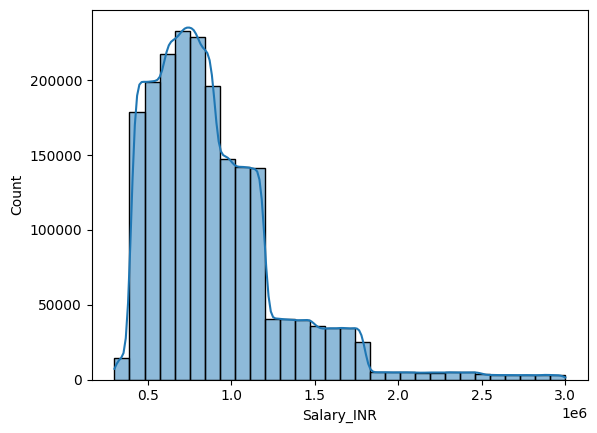

In [17]:
# this is right skewed
sns.histplot(data = df['Salary_INR'],bins = 30,kde = True)

In [34]:
column= ["Salary_INR"]
for col in column:
    q1= df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1

    lower_bound = q1-1.5*IQR
    upper_bound = q3+1.5*IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outliers.shape[0])

69298


In [37]:
column = ["Salary_INR"]
for col in column:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR=q3-q1

    lower_bound= q1-1.5*IQR
    upper_bound= q3+1.5*IQR

    outliers= df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    df[col]= df[col].clip(lower=lower_bound,upper=upper_bound)

In [39]:
column= ["Salary_INR"]
for col in column:
    q1= df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1

    lower_bound = q1-1.5*IQR
    upper_bound = q3+1.5*IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outliers.shape[0])

0


Text(0.5, 1.0, 'detecting outliers')

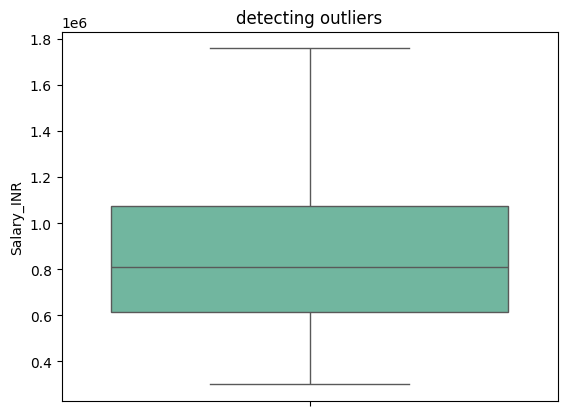

In [40]:
sns.boxplot(data = df['Salary_INR'],palette='BuGn')
plt.title("detecting outliers")

### what is the most department have a more job vacancies ?

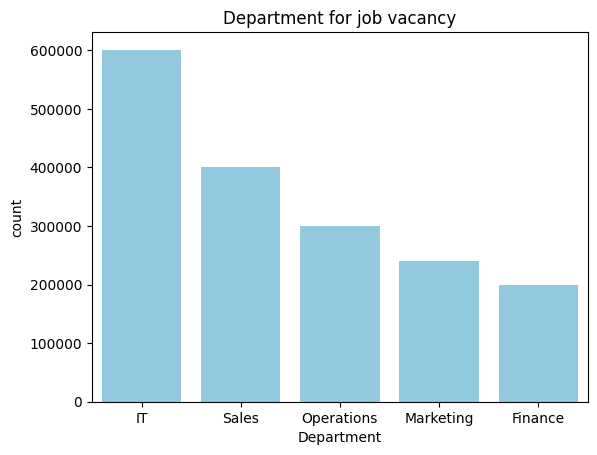

In [41]:
## univariate analysis
dept = df['Department'].value_counts().head()
sns.barplot(data = dept,color = 'skyblue')
plt.title("Department for job vacancy")
plt.show()

### most of the employee working mode ?

Text(0.5, 1.0, 'employee work mode')

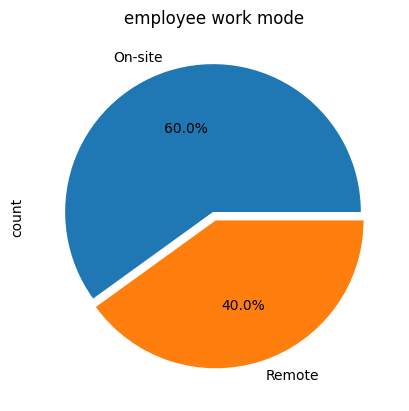

In [56]:
wm = df['Work_Mode'].value_counts().plot(kind = 'pie',autopct= '%1.1f%%', explode=(0.03,0.03))
plt.title("employee work mode")

### which department contain a more salary ?

<Axes: xlabel='Department', ylabel='salary'>

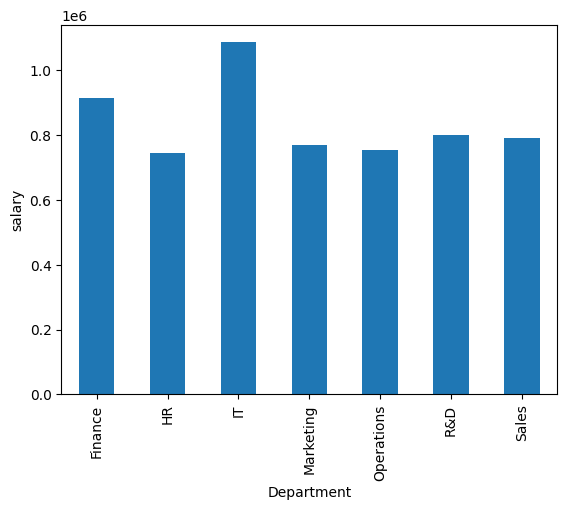

In [43]:
## bivariate analysis
df.groupby('Department')['Salary_INR'].mean().plot(kind = 'bar',stacked = True,ylabel = "salary") #numerical vs categorical

### which year most hiring employee those year

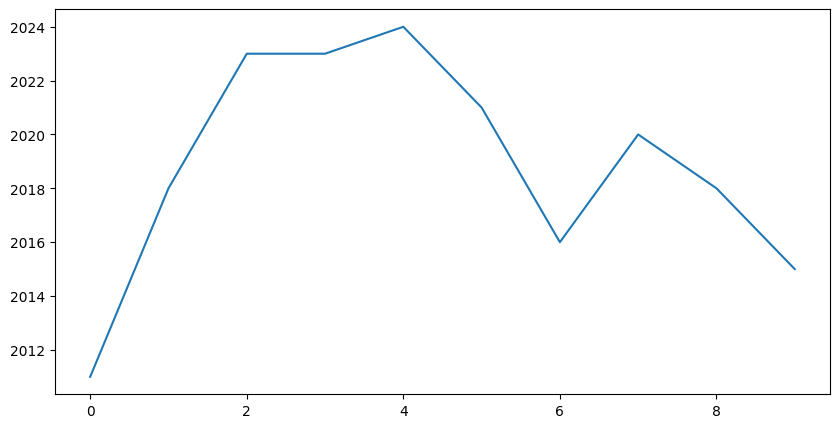

In [69]:
df['Hire_Date'].dt.year.head(10).plot(kind = 'line',figsize = (10,5))
plt.show()

In [83]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


### Are there any job titles with very few employees compared to others?

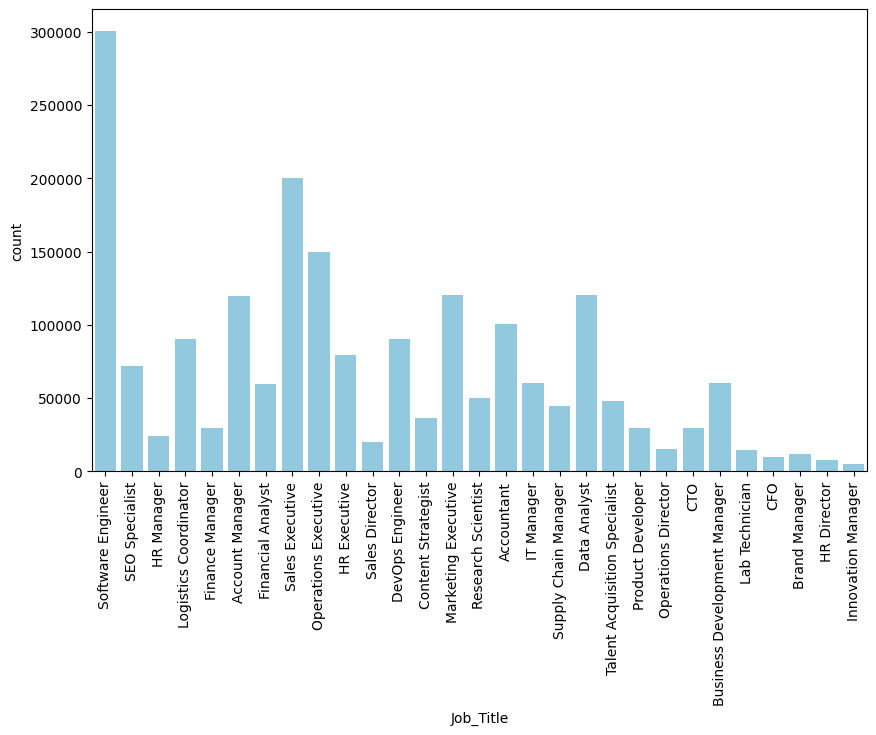

In [67]:
plt.figure(figsize=(10,6))
sns.countplot( x = 'Job_Title', data = df ,color = 'skyblue' )
plt.xticks( rotation = 'vertical')
plt.show()

### most of the employee nowadays status ?

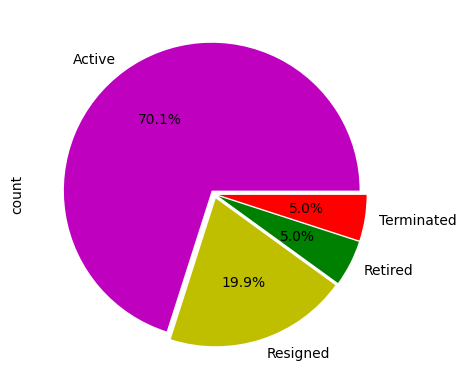

In [70]:
df['Status'].value_counts().plot( kind = 'pie' , colors = 'mygr', autopct= '%1.1f%%', explode=(0.03,0.03,0.03,0.03))
plt.show()

### What is the average salary in different Departments based on Job Title 

In [68]:
dept_job = df.groupby(['Department', 'Job_Title'])['Salary_INR'].mean()/1000
dept_job

Department  Job_Title                    
Finance     Accountant                        650.076482
            CFO                               795.015873
            Finance Manager                  1564.526765
            Financial Analyst                1051.522903
HR          HR Director                       800.694437
            HR Executive                      550.548859
            HR Manager                       1251.656918
            Talent Acquisition Specialist     801.422237
IT          CTO                               801.402754
            Data Analyst                      800.996380
            DevOps Engineer                   799.949184
            IT Manager                       1672.667567
            Software Engineer                1198.578970
Marketing   Brand Manager                     803.127787
            Content Strategist                800.760030
            Marketing Executive               798.780404
            SEO Specialist                    

### How does salary vary with years of experience?

In [74]:
df.groupby(['Experience_Years'])['Salary_INR'].mean()

Experience_Years
0     881414.397262
1     880466.529995
2     880989.710953
3     881195.651970
4     881765.096184
5     880768.120933
6     880759.256956
7     880338.699834
8     881684.701751
9     882984.936203
10    880736.179715
11    884540.342326
12    880591.549123
13    882645.358446
14    880124.701059
15    877542.896891
Name: Salary_INR, dtype: float64

###  What is the average performance rating by department?

In [78]:
df.groupby('Department')['Performance_Rating'].mean()

Department
Finance       2.996818
HR            2.995670
IT            2.998216
Marketing     3.004736
Operations    2.996081
R&D           3.001885
Sales         3.006362
Name: Performance_Rating, dtype: float64

### showing correlation

<Axes: >

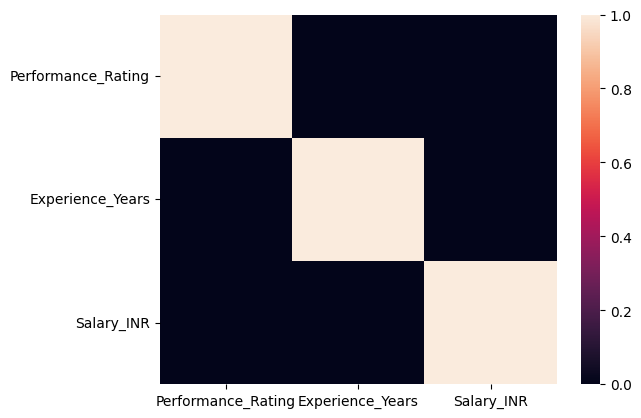

In [84]:
sns.heatmap(df.select_dtypes(include=['number']).corr())